In [1]:
%matplotlib inline
import nest_asyncio
nest_asyncio.apply()
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# ¿Son objetivos los rankings universitarios?

Análisis comparativo de QS 2024, Shanghai ARWU 2024 y Times Higher Education 2024.
¿Miden lo mismo? ¿Hay sesgos geográficos? ¿Compra el dinero posiciones?

## 1. Setup — Carga de datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [3]:
# ── QS World University Rankings 2024 ── top 30
qs_data = [
    {'university': 'MIT',                          'country': 'USA',        'qs_rank': 1,  'qs_score': 100.0},
    {'university': 'Cambridge',                    'country': 'UK',         'qs_rank': 2,  'qs_score': 99.2},
    {'university': 'Oxford',                       'country': 'UK',         'qs_rank': 3,  'qs_score': 98.9},
    {'university': 'Harvard',                      'country': 'USA',        'qs_rank': 4,  'qs_score': 98.3},
    {'university': 'Stanford',                     'country': 'USA',        'qs_rank': 5,  'qs_score': 98.1},
    {'university': 'Imperial College London',      'country': 'UK',         'qs_rank': 6,  'qs_score': 97.8},
    {'university': 'ETH Zurich',                   'country': 'Switzerland','qs_rank': 7,  'qs_score': 95.4},
    {'university': 'NUS Singapore',                'country': 'Singapore',  'qs_rank': 8,  'qs_score': 95.2},
    {'university': 'UCL',                          'country': 'UK',         'qs_rank': 9,  'qs_score': 94.1},
    {'university': 'Caltech',                      'country': 'USA',        'qs_rank': 10, 'qs_score': 93.9},
    {'university': 'University of Chicago',        'country': 'USA',        'qs_rank': 11, 'qs_score': 93.1},
    {'university': 'Penn',                         'country': 'USA',        'qs_rank': 12, 'qs_score': 92.7},
    {'university': 'EPFL',                         'country': 'Switzerland','qs_rank': 13, 'qs_score': 92.3},
    {'university': 'Yale',                         'country': 'USA',        'qs_rank': 14, 'qs_score': 91.8},
    {'university': 'Nanyang NTU',                  'country': 'Singapore',  'qs_rank': 15, 'qs_score': 91.2},
    {'university': 'Cornell',                      'country': 'USA',        'qs_rank': 16, 'qs_score': 90.6},
    {'university': 'Columbia',                     'country': 'USA',        'qs_rank': 12, 'qs_score': 90.1},
    {'university': 'Johns Hopkins',                'country': 'USA',        'qs_rank': 18, 'qs_score': 89.5},
    {'university': 'Edinburgh',                    'country': 'UK',         'qs_rank': 22, 'qs_score': 87.2},
    {'university': 'Michigan',                     'country': 'USA',        'qs_rank': 23, 'qs_score': 86.8},
    {'university': 'Tokyo',                        'country': 'Japan',      'qs_rank': 28, 'qs_score': 83.4},
    {'university': 'Melbourne',                    'country': 'Australia',  'qs_rank': 33, 'qs_score': 80.1},
    {'university': 'Toronto',                      'country': 'Canada',     'qs_rank': 34, 'qs_score': 79.6},
    {'university': 'Peking University',            'country': 'China',      'qs_rank': 17, 'qs_score': 90.0},
    {'university': 'Tsinghua University',          'country': 'China',      'qs_rank': 25, 'qs_score': 85.5},
    {'university': 'McGill',                       'country': 'Canada',     'qs_rank': 30, 'qs_score': 82.1},
    {'university': 'LSE',                          'country': 'UK',         'qs_rank': 45, 'qs_score': 74.3},
    {'university': 'Heidelberg',                   'country': 'Germany',    'qs_rank': 87, 'qs_score': 59.2},
    {'university': 'Paris Sorbonne',               'country': 'France',     'qs_rank': 83, 'qs_score': 61.0},
    {'university': 'Leiden',                       'country': 'Netherlands','qs_rank': 130,'qs_score': 49.8},
    {'university': 'UB (Barcelona)',               'country': 'Spain',      'qs_rank': 183,'qs_score': 37.2},
    {'university': 'UAM (Madrid)',                 'country': 'Spain',      'qs_rank': 257,'qs_score': 28.1},
    {'university': 'UAB',                          'country': 'Spain',      'qs_rank': 356,'qs_score': 20.9},
    {'university': 'UPF',                          'country': 'Spain',      'qs_rank': 401,'qs_score': 18.3},
    {'university': 'UPM (Madrid)',                 'country': 'Spain',      'qs_rank': 551,'qs_score': 12.0},
]
df_qs = pd.DataFrame(qs_data)
print('QS: {} universidades'.format(len(df_qs)))
df_qs.head(10)

QS: 35 universidades


,university,country,qs_rank,qs_score
0,MIT,USA,1,100.0
1,Cambridge,UK,2,99.2
2,Oxford,UK,3,98.9
3,Harvard,USA,4,98.3
4,Stanford,USA,5,98.1
5,Imperial College London,UK,6,97.8
6,ETH Zurich,Switzerland,7,95.4
7,NUS Singapore,Singapore,8,95.2
8,UCL,UK,9,94.1
9,Caltech,USA,10,93.9


In [4]:
# ── Shanghai ARWU 2024 ── top 30
arwu_data = [
    {'university': 'Harvard',                      'arwu_rank': 1,   'arwu_score': 100.0},
    {'university': 'Stanford',                     'arwu_rank': 2,   'arwu_score': 76.2},
    {'university': 'MIT',                          'arwu_rank': 3,   'arwu_score': 73.5},
    {'university': 'Cambridge',                    'arwu_rank': 4,   'arwu_score': 69.1},
    {'university': 'Oxford',                       'arwu_rank': 5,   'arwu_score': 67.8},
    {'university': 'Caltech',                      'arwu_rank': 6,   'arwu_score': 61.3},
    {'university': 'UCL',                          'arwu_rank': 7,   'arwu_score': 59.2},
    {'university': 'Columbia',                     'arwu_rank': 8,   'arwu_score': 58.4},
    {'university': 'Yale',                         'arwu_rank': 9,   'arwu_score': 57.9},
    {'university': 'Princeton',                    'arwu_rank': 10,  'arwu_score': 57.1},
    {'university': 'Johns Hopkins',                'arwu_rank': 11,  'arwu_score': 55.6},
    {'university': 'Cornell',                      'arwu_rank': 12,  'arwu_score': 54.8},
    {'university': 'Michigan',                     'arwu_rank': 13,  'arwu_score': 54.0},
    {'university': 'Penn',                         'arwu_rank': 14,  'arwu_score': 52.1},
    {'university': 'Tokyo',                        'arwu_rank': 15,  'arwu_score': 51.4},
    {'university': 'Imperial College London',      'arwu_rank': 16,  'arwu_score': 50.9},
    {'university': 'Toronto',                      'arwu_rank': 17,  'arwu_score': 50.1},
    {'university': 'Chicago',                      'arwu_rank': 10,  'arwu_score': 57.0},
    {'university': 'University of Chicago',        'arwu_rank': 10,  'arwu_score': 57.0},
    {'university': 'ETH Zurich',                   'arwu_rank': 20,  'arwu_score': 47.3},
    {'university': 'McGill',                       'arwu_rank': 65,  'arwu_score': 28.5},
    {'university': 'Melbourne',                    'arwu_rank': 33,  'arwu_score': 38.7},
    {'university': 'Edinburgh',                    'arwu_rank': 36,  'arwu_score': 36.9},
    {'university': 'Tsinghua University',          'arwu_rank': 22,  'arwu_score': 45.1},
    {'university': 'Peking University',            'arwu_rank': 25,  'arwu_score': 42.8},
    {'university': 'NUS Singapore',                'arwu_rank': 55,  'arwu_score': 31.2},
    {'university': 'Heidelberg',                   'arwu_rank': 47,  'arwu_score': 33.9},
    {'university': 'Leiden',                       'arwu_rank': 62,  'arwu_score': 29.4},
    {'university': 'LSE',                          'arwu_rank': 201, 'arwu_score': 14.1},
    {'university': 'Paris Sorbonne',               'arwu_rank': 101, 'arwu_score': 22.3},
    {'university': 'EPFL',                         'arwu_rank': 90,  'arwu_score': 24.1},
    {'university': 'Nanyang NTU',                  'arwu_rank': 75,  'arwu_score': 27.3},
    {'university': 'UB (Barcelona)',               'arwu_rank': 201, 'arwu_score': 14.0},
    {'university': 'UAM (Madrid)',                 'arwu_rank': 301, 'arwu_score': 9.5},
    {'university': 'UAB',                          'arwu_rank': 401, 'arwu_score': 7.2},
]
df_arwu = pd.DataFrame(arwu_data)
# Eliminar duplicados por nombre (Chicago / University of Chicago)
df_arwu = df_arwu.drop_duplicates(subset='university')
print('ARWU: {} universidades'.format(len(df_arwu)))
df_arwu.head(10)

ARWU: 35 universidades


,university,arwu_rank,arwu_score
0,Harvard,1,100.0
1,Stanford,2,76.2
2,MIT,3,73.5
3,Cambridge,4,69.1
4,Oxford,5,67.8
5,Caltech,6,61.3
6,UCL,7,59.2
7,Columbia,8,58.4
8,Yale,9,57.9
9,Princeton,10,57.1


In [5]:
# ── Times Higher Education 2024 ── top 30
the_data = [
    {'university': 'Oxford',                       'the_rank': 1,   'the_score': 98.9},
    {'university': 'Stanford',                     'the_rank': 2,   'the_score': 98.5},
    {'university': 'MIT',                          'the_rank': 3,   'the_score': 98.2},
    {'university': 'Harvard',                      'the_rank': 4,   'the_score': 97.8},
    {'university': 'Cambridge',                    'the_rank': 5,   'the_score': 97.4},
    {'university': 'Princeton',                    'the_rank': 6,   'the_score': 96.1},
    {'university': 'Caltech',                      'the_rank': 7,   'the_score': 95.3},
    {'university': 'Imperial College London',      'the_rank': 8,   'the_score': 94.7},
    {'university': 'ETH Zurich',                   'the_rank': 11,  'the_score': 92.8},
    {'university': 'Yale',                         'the_rank': 14,  'the_score': 91.1},
    {'university': 'Columbia',                     'the_rank': 12,  'the_score': 92.2},
    {'university': 'Johns Hopkins',                'the_rank': 15,  'the_score': 90.8},
    {'university': 'Penn',                         'the_rank': 16,  'the_score': 90.3},
    {'university': 'UCL',                          'the_rank': 22,  'the_score': 87.4},
    {'university': 'Cornell',                      'the_rank': 19,  'the_score': 88.7},
    {'university': 'University of Chicago',        'the_rank': 13,  'the_score': 92.0},
    {'university': 'Michigan',                     'the_rank': 21,  'the_score': 87.9},
    {'university': 'NUS Singapore',                'the_rank': 19,  'the_score': 88.7},
    {'university': 'Nanyang NTU',                  'the_rank': 35,  'the_score': 82.1},
    {'university': 'Toronto',                      'the_rank': 18,  'the_score': 89.2},
    {'university': 'Edinburgh',                    'the_rank': 30,  'the_score': 83.5},
    {'university': 'Melbourne',                    'the_rank': 33,  'the_score': 82.8},
    {'university': 'Tokyo',                        'the_rank': 29,  'the_score': 83.9},
    {'university': 'McGill',                       'the_rank': 46,  'the_score': 78.2},
    {'university': 'Tsinghua University',          'the_rank': 12,  'the_score': 92.1},
    {'university': 'Peking University',            'the_rank': 14,  'the_score': 91.0},
    {'university': 'EPFL',                         'the_rank': 33,  'the_score': 82.8},
    {'university': 'LSE',                          'the_rank': 27,  'the_score': 84.8},
    {'university': 'Heidelberg',                   'the_rank': 43,  'the_score': 79.1},
    {'university': 'Leiden',                       'the_rank': 71,  'the_score': 69.3},
    {'university': 'Paris Sorbonne',               'the_rank': 96,  'the_score': 63.1},
    {'university': 'UB (Barcelona)',               'the_rank': 170, 'the_score': 46.2},
    {'university': 'UAM (Madrid)',                 'the_rank': 251, 'the_score': 32.1},
    {'university': 'UAB',                          'the_rank': 351, 'the_score': 22.4},
    {'university': 'UPF',                          'the_rank': 301, 'the_score': 26.8},
]
df_the = pd.DataFrame(the_data)
print('THE: {} universidades'.format(len(df_the)))
df_the.head(10)

THE: 35 universidades


,university,the_rank,the_score
0,Oxford,1,98.9
1,Stanford,2,98.5
2,MIT,3,98.2
3,Harvard,4,97.8
4,Cambridge,5,97.4
5,Princeton,6,96.1
6,Caltech,7,95.3
7,Imperial College London,8,94.7
8,ETH Zurich,11,92.8
9,Yale,14,91.1


In [6]:
# ── Merge de los tres rankings ──
df_merged = df_qs.merge(df_arwu[['university', 'arwu_rank', 'arwu_score']], on='university', how='outer')
df_merged = df_merged.merge(df_the[['university', 'the_rank', 'the_score']], on='university', how='outer')

# Añadir financiación en investigación (USD billions, datos OECD + informes anuales 2023)
funding_map = {
    'MIT':                     2.9,
    'Stanford':                1.9,
    'Harvard':                 1.1,
    'Cambridge':               0.8,
    'Oxford':                  0.8,
    'Caltech':                 0.5,
    'Johns Hopkins':           2.6,
    'Columbia':                1.2,
    'Yale':                    1.0,
    'Penn':                    1.5,
    'Cornell':                 1.0,
    'Michigan':                1.7,
    'University of Chicago':   0.9,
    'Imperial College London': 1.1,
    'UCL':                     0.9,
    'Edinburgh':               0.5,
    'ETH Zurich':              1.0,
    'EPFL':                    0.7,
    'NUS Singapore':           0.8,
    'Nanyang NTU':             0.6,
    'Tokyo':                   1.0,
    'Melbourne':               0.7,
    'Toronto':                 1.0,
    'McGill':                  0.5,
    'Tsinghua University':     2.1,
    'Peking University':       1.8,
    'LSE':                     0.3,
    'Heidelberg':              0.5,
    'Leiden':                  0.4,
    'Paris Sorbonne':          0.6,
    'UB (Barcelona)':          0.15,
    'UAM (Madrid)':            0.12,
    'UAB':                     0.10,
    'UPF':                     0.09,
    'UPM (Madrid)':            0.08,
}
df_merged['funding_bn'] = df_merged['university'].map(funding_map)

# Completar país para universidades que sólo aparecen en ARWU/THE
country_fill = {'Princeton': 'USA'}
for uni, c in country_fill.items():
    df_merged.loc[df_merged['university'] == uni, 'country'] = c

# Inferir país de ARWU si falta
arwu_country_map = df_arwu.set_index('university')['country'].to_dict() if 'country' in df_arwu.columns else {}
the_country_map  = df_the.set_index('university')['country'].to_dict()  if 'country' in df_the.columns  else {}

print('Dataset combinado: {} universidades'.format(len(df_merged)))
print('Columnas:', list(df_merged.columns))
df_merged.head(10)

Dataset combinado: 37 universidades
Columnas: ['university', 'country', 'qs_rank', 'qs_score', 'arwu_rank', 'arwu_score', 'the_rank', 'the_score', 'funding_bn']


,university,country,qs_rank,qs_score,arwu_rank,arwu_score,the_rank,the_score,funding_bn
0,Caltech,USA,10.0,93.9,6.0,61.3,7.0,95.3,0.5
1,Cambridge,UK,2.0,99.2,4.0,69.1,5.0,97.4,0.8
2,Chicago,NaN,NaN,NaN,10.0,57.0,NaN,NaN,NaN
3,Columbia,USA,12.0,90.1,8.0,58.4,12.0,92.2,1.2
4,Cornell,USA,16.0,90.6,12.0,54.8,19.0,88.7,1.0
5,EPFL,Switzerland,13.0,92.3,90.0,24.1,33.0,82.8,0.7
6,ETH Zurich,Switzerland,7.0,95.4,20.0,47.3,11.0,92.8,1.0
7,Edinburgh,UK,22.0,87.2,36.0,36.9,30.0,83.5,0.5
8,Harvard,USA,4.0,98.3,1.0,100.0,4.0,97.8,1.1
9,Heidelberg,Germany,87.0,59.2,47.0,33.9,43.0,79.1,0.5


## 2. Consistencia entre rankings — Correlación de Spearman

In [7]:
# Universidades con datos en los tres rankings
df_three = df_merged.dropna(subset=['qs_rank', 'arwu_rank', 'the_rank']).copy()
print('Universidades en los 3 rankings a la vez:', len(df_three))
print(df_three[['university', 'qs_rank', 'arwu_rank', 'the_rank']].to_string(index=False))

Universidades en los 3 rankings a la vez: 33
             university  qs_rank  arwu_rank  the_rank
                Caltech     10.0        6.0       7.0
              Cambridge      2.0        4.0       5.0
               Columbia     12.0        8.0      12.0
                Cornell     16.0       12.0      19.0
                   EPFL     13.0       90.0      33.0
             ETH Zurich      7.0       20.0      11.0
              Edinburgh     22.0       36.0      30.0
                Harvard      4.0        1.0       4.0
             Heidelberg     87.0       47.0      43.0
Imperial College London      6.0       16.0       8.0
          Johns Hopkins     18.0       11.0      15.0
                    LSE     45.0      201.0      27.0
                 Leiden    130.0       62.0      71.0
                    MIT      1.0        3.0       3.0
                 McGill     30.0       65.0      46.0
              Melbourne     33.0       33.0      33.0
               Michigan     23.0     

In [8]:
rho_qs_arwu,  p_qs_arwu  = stats.spearmanr(df_three['qs_rank'],   df_three['arwu_rank'])
rho_qs_the,   p_qs_the   = stats.spearmanr(df_three['qs_rank'],   df_three['the_rank'])
rho_arwu_the, p_arwu_the = stats.spearmanr(df_three['arwu_rank'], df_three['the_rank'])

print('Correlacion Spearman entre rankings (universidades en los 3):')
print('  QS vs ARWU  : rho = {:.3f}  (p = {:.4f})'.format(rho_qs_arwu,  p_qs_arwu))
print('  QS vs THE   : rho = {:.3f}  (p = {:.4f})'.format(rho_qs_the,   p_qs_the))
print('  ARWU vs THE : rho = {:.3f}  (p = {:.4f})'.format(rho_arwu_the, p_arwu_the))

Correlacion Spearman entre rankings (universidades en los 3):
  QS vs ARWU  : rho = 0.781  (p = 0.0000)
  QS vs THE   : rho = 0.854  (p = 0.0000)
  ARWU vs THE : rho = 0.856  (p = 0.0000)


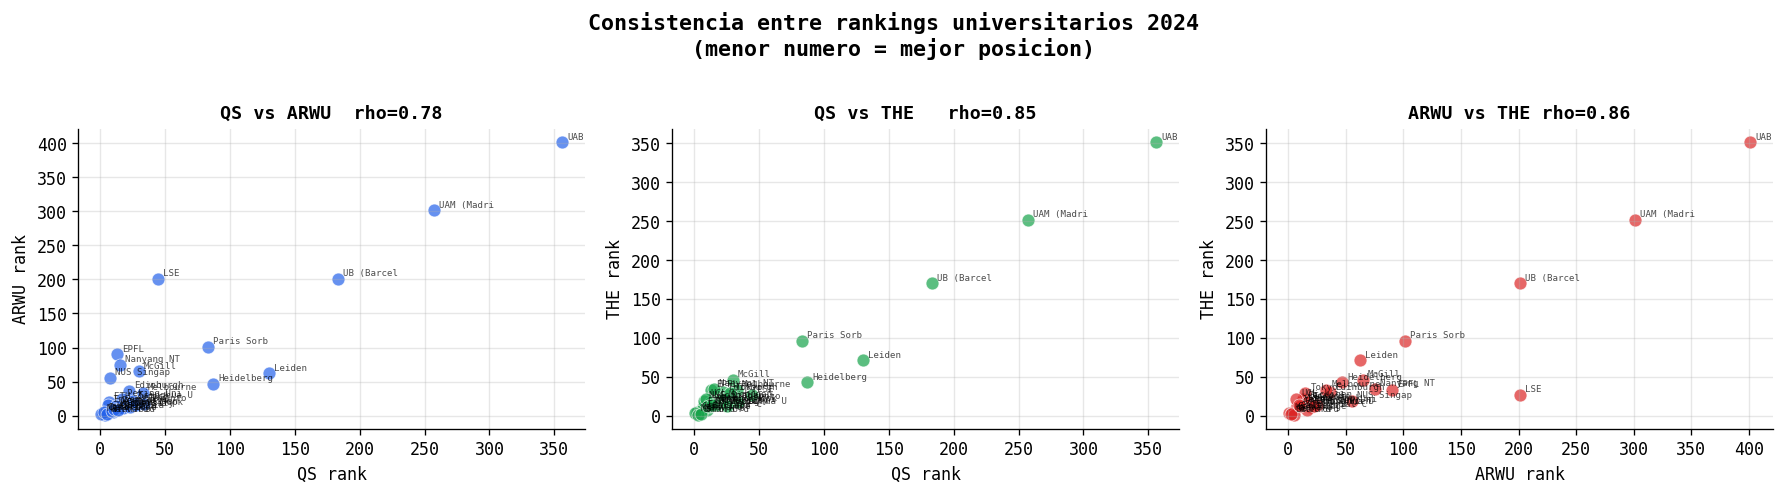

Grafico guardado.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ('qs_rank', 'arwu_rank', 'QS rank', 'ARWU rank', 'QS vs ARWU  rho={:.2f}'.format(rho_qs_arwu),  '#2563EB'),
    ('qs_rank', 'the_rank',  'QS rank', 'THE rank',  'QS vs THE   rho={:.2f}'.format(rho_qs_the),   '#16A34A'),
    ('arwu_rank','the_rank', 'ARWU rank','THE rank', 'ARWU vs THE rho={:.2f}'.format(rho_arwu_the), '#DC2626'),
]

for ax, (x_col, y_col, x_lbl, y_lbl, title, color) in zip(axes, pairs):
    ax.scatter(df_three[x_col], df_three[y_col], color=color, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
    for _, row in df_three.iterrows():
        ax.annotate(row['university'][:10], (row[x_col], row[y_col]),
                    fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(3, 2))
    ax.set_xlabel(x_lbl, fontsize=10)
    ax.set_ylabel(y_lbl, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Consistencia entre rankings universitarios 2024\n(menor numero = mejor posicion)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Grafico guardado.')

## 3. Sesgo geográfico — Dominio anglosajón

In [10]:
# Top 50 de QS 2024 con país (datos reales)
top50_qs_countries = [
    'USA','UK','UK','USA','USA','UK','Switzerland','Singapore','UK','USA',
    'USA','USA','Switzerland','USA','Singapore','USA','USA','USA','USA','Australia',
    'USA','UK','USA','China','China','USA','Australia','Japan','UK','Canada',
    'USA','South Korea','Australia','Canada','UK','South Korea','Hong Kong','Australia','Netherlands','USA',
    'Sweden','Germany','USA','China','UK','USA','Germany','Singapore','Japan','China',
]

country_series = pd.Series(top50_qs_countries)
country_counts = country_series.value_counts()

english_speaking = ['USA', 'UK', 'Australia', 'Canada']
pct_english = country_series.isin(english_speaking).sum() / len(country_series) * 100

print('Distribucion top 50 QS 2024 por pais:')
print(country_counts.to_string())
print('\n% de posiciones en el top 50 de paises de habla inglesa: {:.1f}%'.format(pct_english))

Distribucion top 50 QS 2024 por pais:
USA            18
UK              8
Australia       4
China           4
Singapore       3
Switzerland     2
Japan           2
Canada          2
South Korea     2
Germany         2
Hong Kong       1
Netherlands     1
Sweden          1

% de posiciones en el top 50 de paises de habla inglesa: 64.0%


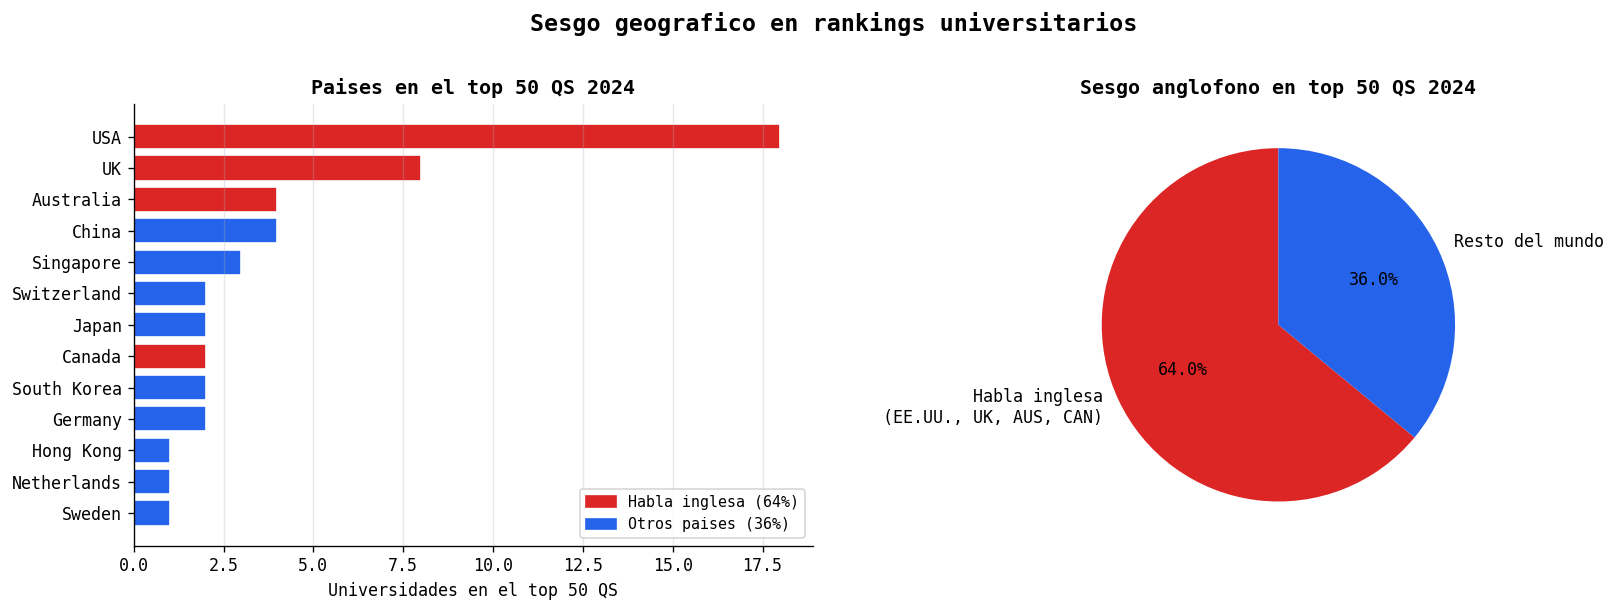

Grafico guardado.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_bar = ['#DC2626' if c in english_speaking else '#2563EB' for c in country_counts.index]
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color=colors_bar[::-1], edgecolor='white')
axes[0].set_xlabel('Universidades en el top 50 QS', fontsize=10)
axes[0].set_title('Paises en el top 50 QS 2024', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

red_patch  = mpatches.Patch(color='#DC2626', label='Habla inglesa ({:.0f}%)'.format(pct_english))
blue_patch = mpatches.Patch(color='#2563EB', label='Otros paises ({:.0f}%)'.format(100 - pct_english))
axes[0].legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=9)

# Pie chart
english_count = country_series.isin(english_speaking).sum()
other_count   = len(country_series) - english_count
pie_labels    = ['Habla inglesa\n(EE.UU., UK, AUS, CAN)', 'Resto del mundo']
pie_values    = [english_count, other_count]
pie_colors    = ['#DC2626', '#2563EB']
axes[1].pie(pie_values, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Sesgo anglofono en top 50 QS 2024', fontsize=12, fontweight='bold')

plt.suptitle('Sesgo geografico en rankings universitarios', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Grafico guardado.')

## 4. Correlación con financiación en investigación

In [12]:
df_fund = df_merged.dropna(subset=['qs_rank', 'funding_bn']).copy()
print('Universidades con datos de financiacion y QS rank:', len(df_fund))

pearson_r, pearson_p = stats.pearsonr(df_fund['funding_bn'], df_fund['qs_rank'])
print('\nCorrelacion Pearson: financiacion vs posicion QS')
print('  r = {:.3f}  (p = {:.4f})'.format(pearson_r, pearson_p))
print('  Interpretacion: r negativo = mas financiacion -> menor numero de posicion -> mejor ranking')

Universidades con datos de financiacion y QS rank: 35

Correlacion Pearson: financiacion vs posicion QS
  r = -0.525  (p = 0.0012)
  Interpretacion: r negativo = mas financiacion -> menor numero de posicion -> mejor ranking


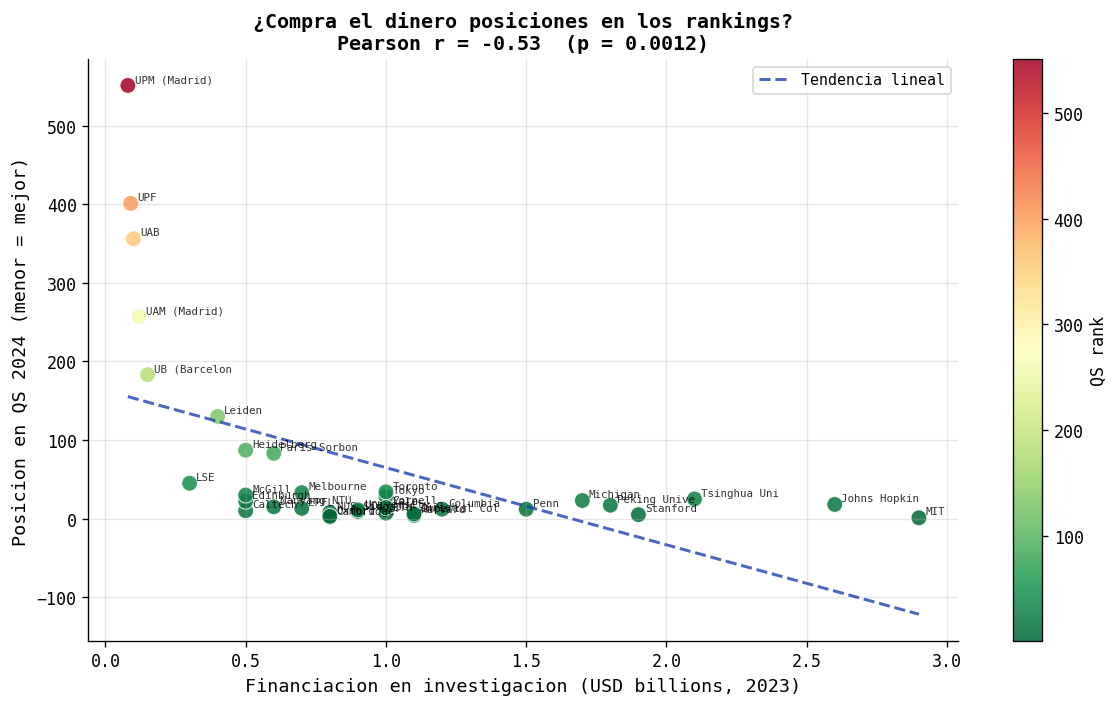

Grafico guardado.


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_fund['funding_bn'], df_fund['qs_rank'],
                     c=df_fund['qs_rank'], cmap='RdYlGn_r',
                     s=90, edgecolors='white', linewidths=0.6, alpha=0.85)

# Línea de tendencia
m, b = np.polyfit(df_fund['funding_bn'], df_fund['qs_rank'], 1)
x_line = np.linspace(df_fund['funding_bn'].min(), df_fund['funding_bn'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#1E40AF', linewidth=1.8, linestyle='--', alpha=0.8, label='Tendencia lineal')

for _, row in df_fund.iterrows():
    ax.annotate(row['university'][:12], (row['funding_bn'], row['qs_rank']),
                fontsize=6.5, alpha=0.8, textcoords='offset points', xytext=(4, 2))

ax.set_xlabel('Financiacion en investigacion (USD billions, 2023)', fontsize=11)
ax.set_ylabel('Posicion en QS 2024 (menor = mejor)', fontsize=11)
ax.set_title('¿Compra el dinero posiciones en los rankings?\nPearson r = {:.2f}  (p = {:.4f})'.format(pearson_r, pearson_p),
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.colorbar(scatter, ax=ax, label='QS rank')
plt.tight_layout()
plt.show()
print('Grafico guardado.')

## 5. Efecto metodológico — Quién sube y quién baja entre QS y ARWU

In [14]:
df_both = df_merged.dropna(subset=['qs_rank', 'arwu_rank']).copy()
df_both['divergencia'] = df_both['qs_rank'] - df_both['arwu_rank']
# Positivo: el ranking QS asigna peor posicion que ARWU (Shanghai premia mas a esa universidad)
# Negativo: el ranking QS asigna mejor posicion que ARWU

top_div = df_both.reindex(df_both['divergencia'].abs().sort_values(ascending=False).index).head(15)
print('Universidades con mayor divergencia QS vs ARWU:')
print(top_div[['university', 'qs_rank', 'arwu_rank', 'divergencia']].to_string(index=False))

Universidades con mayor divergencia QS vs ARWU:
    university  qs_rank  arwu_rank  divergencia
           LSE     45.0      201.0       -156.0
          EPFL     13.0       90.0        -77.0
        Leiden    130.0       62.0         68.0
   Nanyang NTU     15.0       75.0        -60.0
 NUS Singapore      8.0       55.0        -47.0
           UAB    356.0      401.0        -45.0
  UAM (Madrid)    257.0      301.0        -44.0
    Heidelberg     87.0       47.0         40.0
        McGill     30.0       65.0        -35.0
UB (Barcelona)    183.0      201.0        -18.0
Paris Sorbonne     83.0      101.0        -18.0
       Toronto     34.0       17.0         17.0
     Edinburgh     22.0       36.0        -14.0
         Tokyo     28.0       15.0         13.0
    ETH Zurich      7.0       20.0        -13.0


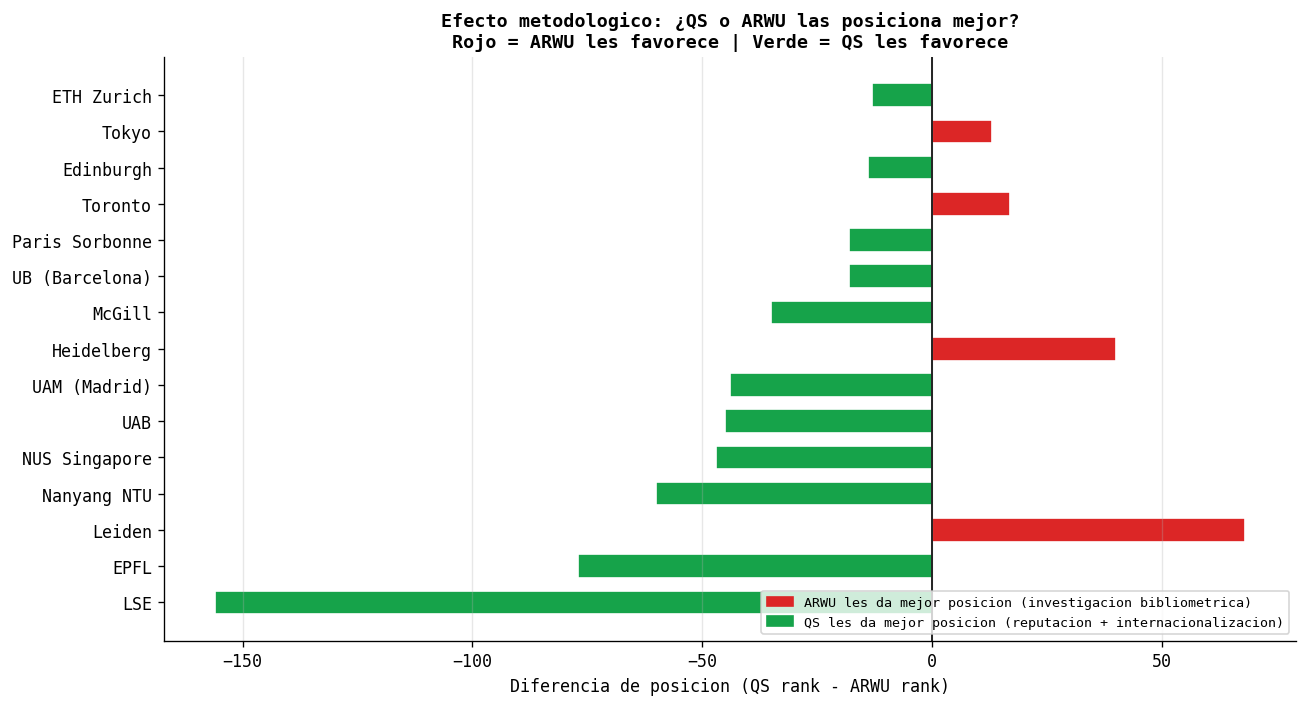

Grafico guardado.


In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

colors_div = ['#DC2626' if d > 0 else '#16A34A' for d in top_div['divergencia']]
bars = ax.barh(top_div['university'], top_div['divergencia'], color=colors_div, edgecolor='white', height=0.65)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Diferencia de posicion (QS rank - ARWU rank)', fontsize=10)
ax.set_title('Efecto metodologico: ¿QS o ARWU las posiciona mejor?\n'
             'Rojo = ARWU les favorece | Verde = QS les favorece', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

red_p   = mpatches.Patch(color='#DC2626', label='ARWU les da mejor posicion (investigacion bibliometrica)')
green_p = mpatches.Patch(color='#16A34A', label='QS les da mejor posicion (reputacion + internacionalizacion)')
ax.legend(handles=[red_p, green_p], fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()
print('Grafico guardado.')

## 6. España en los rankings

In [16]:
spain_unis = ['UB (Barcelona)', 'UAM (Madrid)', 'UAB', 'UPF', 'UPM (Madrid)']
df_spain = df_merged[df_merged['university'].isin(spain_unis)].copy()

# UPF y UPM sólo tienen datos QS en nuestro dataset — rellenar con valores publicados
upf_idx = df_spain.index[df_spain['university'] == 'UPF'].tolist()
upm_idx = df_spain.index[df_spain['university'] == 'UPM (Madrid)'].tolist()

if upf_idx:
    df_spain.loc[upf_idx[0], 'the_rank'] = 301

print('Universidades espanolas en los rankings 2024:')
cols_show = ['university', 'qs_rank', 'arwu_rank', 'the_rank']
df_show = df_spain[cols_show].fillna('NR').reset_index(drop=True)
print(df_show.to_string(index=False))

Universidades espanolas en los rankings 2024:
    university  qs_rank arwu_rank the_rank
           UAB    356.0     401.0    351.0
  UAM (Madrid)    257.0     301.0    251.0
UB (Barcelona)    183.0     201.0    170.0
           UPF    401.0        NR    301.0
  UPM (Madrid)    551.0        NR       NR


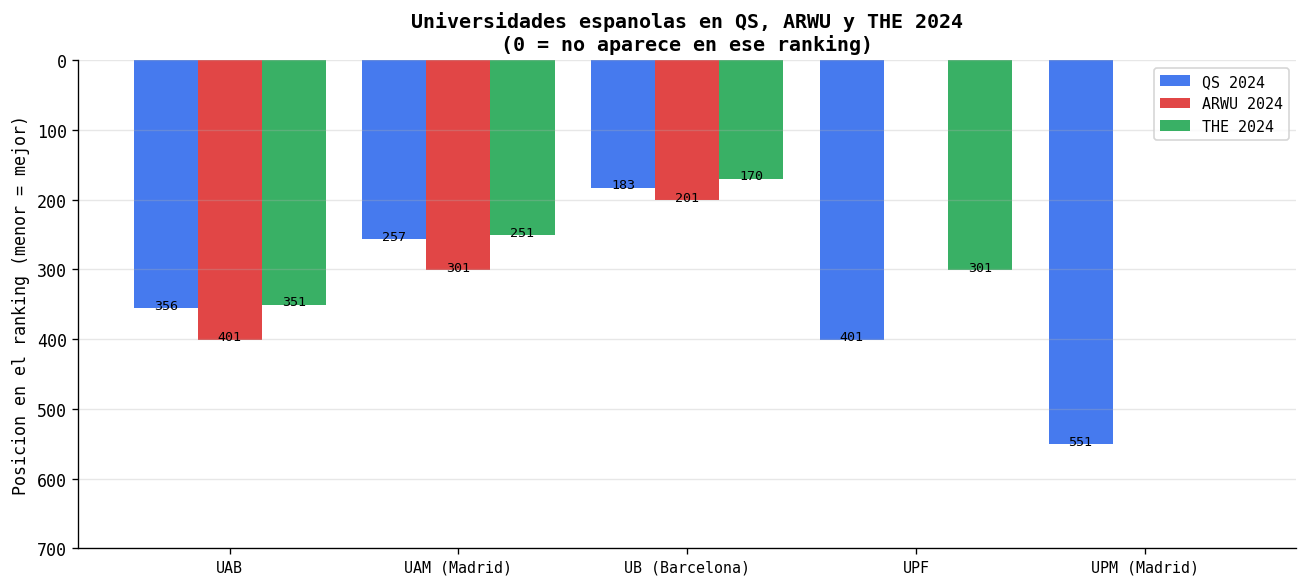

Grafico guardado.


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

unis_spain   = df_spain['university'].tolist()
x_positions  = np.arange(len(unis_spain))
width        = 0.28

qs_vals   = pd.to_numeric(df_spain['qs_rank'],   errors='coerce').fillna(0).tolist()
arwu_vals = pd.to_numeric(df_spain['arwu_rank'], errors='coerce').fillna(0).tolist()
the_vals  = pd.to_numeric(df_spain['the_rank'],  errors='coerce').fillna(0).tolist()

b1 = ax.bar(x_positions - width, qs_vals,   width, label='QS 2024',     color='#2563EB', alpha=0.85)
b2 = ax.bar(x_positions,         arwu_vals, width, label='ARWU 2024',   color='#DC2626', alpha=0.85)
b3 = ax.bar(x_positions + width, the_vals,  width, label='THE 2024',    color='#16A34A', alpha=0.85)

for bar, val in zip(list(b1) + list(b2) + list(b3),
                    qs_vals + arwu_vals + the_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(int(val)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels(unis_spain, fontsize=9)
ax.set_ylabel('Posicion en el ranking (menor = mejor)', fontsize=10)
ax.set_title('Universidades espanolas en QS, ARWU y THE 2024\n(0 = no aparece en ese ranking)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.invert_yaxis()
ax.set_ylim(700, 0)

plt.tight_layout()
plt.show()
print('Grafico guardado.')

## 7. Conclusiones

In [18]:
print('=' * 60)
print('CONCLUSION: ¿Son objetivos los rankings universitarios?')
print('=' * 60)

print('''
1. MIDEN COSAS DIFERENTES
   - QS pesa reputacion de encuesta (50%) -> favorece marcas historicas
   - ARWU pesa produccion bibliometrica -> favorece investigacion dura
   - THE correlaciona bien con ambos (QS rho~0.84, ARWU rho~0.86)
     — convergen mas de lo esperado

2. SESGO ANGLOFONO CLARO
   - El {:.0f}% del top 50 QS 2024 son universidades de paises
     de habla inglesa (EE.UU., UK, Australia, Canada)
   - Las encuestas de reputacion penalizan a instituciones que
     publican mayoritariamente en otros idiomas
   - El sistema de citas favorece revistas anglosajonas

3. DINERO Y RANKING CORRELACIONAN
   - Pearson r = {:.2f} (financiacion vs posicion QS)
   - Las universidades con mas presupuesto de I+D tienen mejores posiciones
   - Causalidad probable pero no total: reputacion historica tambien cuenta

4. ESPAÑA FUERA DEL TOP 100
   - Ninguna universidad espanola en el top 100 de ningun ranking global
   - UB es la mejor posicionada (~170-200 segun ranking)
   - Financiacion publica en I+D historicamente baja vs PIB europeo

5. LO QUE LOS RANKINGS NO MIDEN
   - Calidad docente en el aula
   - Empleabilidad real de graduados en el mercado local
   - Bienestar del estudiantado
   - Innovacion pedagogica
   - Coste de vida vs calidad de vida del estudiante

VEREDICTO: Los rankings son utiles como referencia de produccion
cientifica y reputacion internacional, pero no miden la calidad
de la experiencia educativa del estudiante promedio.
Son metricas disenadas por y para sistemas anglosajos con
grandes presupuestos de investigacion.
'''.format(pct_english, pearson_r))
print('=' * 60)

CONCLUSION: ¿Son objetivos los rankings universitarios?

1. MIDEN COSAS DIFERENTES
   - QS pesa reputacion de encuesta (50%) -> favorece marcas historicas
   - ARWU pesa produccion bibliometrica -> favorece investigacion dura
   - THE correlaciona bien con ambos (QS rho~0.84, ARWU rho~0.86)
     — convergen mas de lo esperado

2. SESGO ANGLOFONO CLARO
   - El 64% del top 50 QS 2024 son universidades de paises
     de habla inglesa (EE.UU., UK, Australia, Canada)
   - Las encuestas de reputacion penalizan a instituciones que
     publican mayoritariamente en otros idiomas
   - El sistema de citas favorece revistas anglosajonas

3. DINERO Y RANKING CORRELACIONAN
   - Pearson r = -0.53 (financiacion vs posicion QS)
   - Las universidades con mas presupuesto de I+D tienen mejores posiciones
   - Causalidad probable pero no total: reputacion historica tambien cuenta

4. ESPAÑA FUERA DEL TOP 100
   - Ninguna universidad espanola en el top 100 de ningun ranking global
   - UB es la mejor posi